In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [3]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    feature_names = X.columns
    return feature_names

In [7]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

## cross-validation

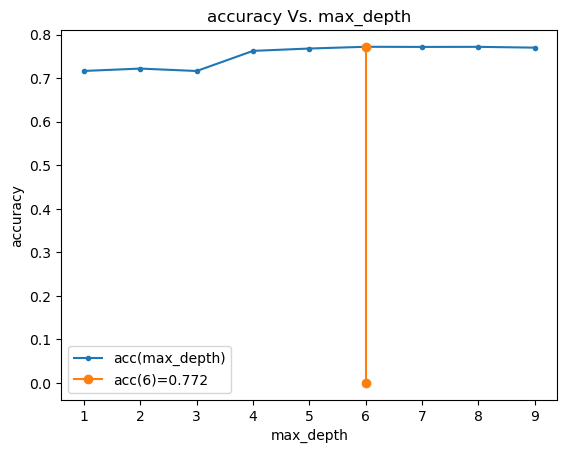

In [69]:
X,Y = LoadData("X_data.csv","Y_data.csv")
X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
clf = DecisionTreeClassifier()

running_num = 30
maxDepth_arr = np.arange(1,10,1)
acc_total = np.array([])

for maxDepth in maxDepth_arr:
    # initial conditions
    acc = np.array([])
    clf.set_params(max_depth = maxDepth)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc,clf.score(X_test,Y_test))
        #acc = np.append(acc,(clf.predict(X_test)==Y_test).mean())
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(maxDepth_arr,acc_total,'.-')
plt.plot([maxDepth_arr[acc_total.argmax()],maxDepth_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('accuracy Vs. max_depth')    
plt.legend(['acc(max_depth)',f'acc({maxDepth_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()



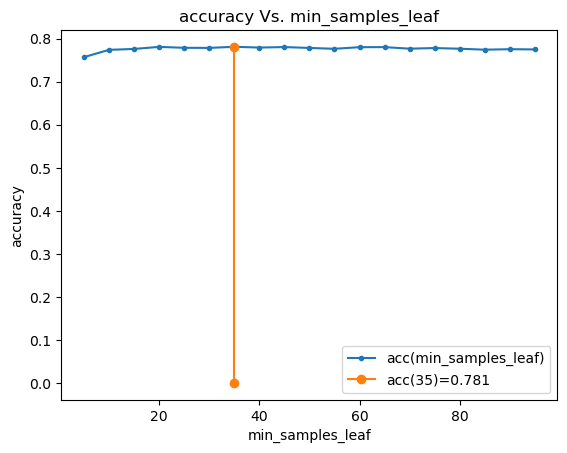

In [35]:
X,Y = LoadData("X_data.csv","Y_data.csv")
Kmax = 30
running_num = 30
MinSamplesLeaf_arr = np.arange(5,100,5)
clf = DecisionTreeClassifier()
acc_total = np.array([])

for MinSamplesLeaf in MinSamplesLeaf_arr:
    acc = np.array([])
    clf.set_params(min_samples_leaf = MinSamplesLeaf)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc,clf.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(MinSamplesLeaf_arr,acc_total,'.-')
plt.plot([MinSamplesLeaf_arr[acc_total.argmax()],MinSamplesLeaf_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('min_samples_leaf')
plt.ylabel('accuracy')
plt.title('accuracy Vs. min_samples_leaf')    
plt.legend(['acc(min_samples_leaf)',f'acc({MinSamplesLeaf_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()



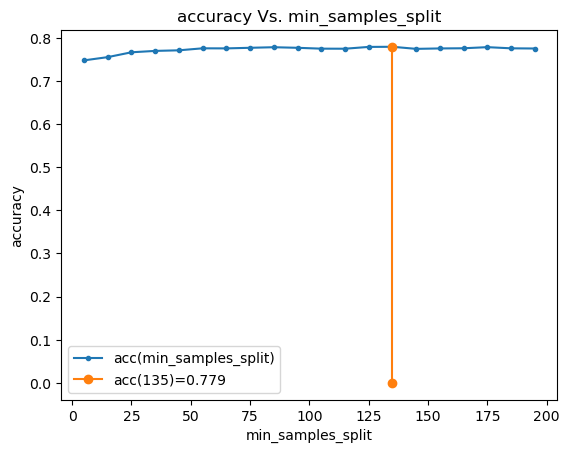

In [61]:
X,Y = LoadData("X_data.csv","Y_data.csv")
Kmax = 20
running_num = 30
MinSamplesSplit_arr = np.arange(5,200,10)
clf = DecisionTreeClassifier()
acc_total = np.array([])

for MinSamplesSplit in MinSamplesSplit_arr:
    acc = np.array([])
    clf.set_params(min_samples_split = MinSamplesSplit)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc,clf.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(MinSamplesSplit_arr,acc_total,'.-')
plt.plot([MinSamplesSplit_arr[acc_total.argmax()],MinSamplesSplit_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.title('accuracy Vs. min_samples_split')    
plt.legend(['acc(min_samples_split)',f'acc({MinSamplesSplit_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()



## Optimum parameters 

In [77]:
X,Y = LoadData("X_data.csv","Y_data.csv")

running_num = 40
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    clf = DecisionTreeClassifier(max_depth=7,min_samples_split=135,min_samples_leaf=35).fit(X_train,Y_train)
    acc = np.append(acc,clf.score(X_test,Y_test))
acc.mean()

0.7723778307508938

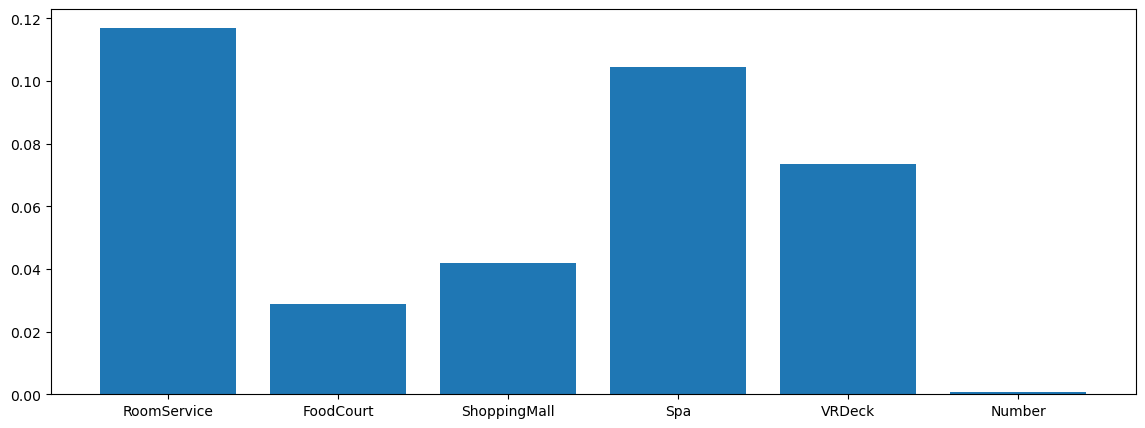

In [35]:
from sklearn.inspection import permutation_importance
feature_names = GetFeatureNames("X_data.csv")
result = permutation_importance(clf, X_test, Y_test, n_repeats=30, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(14,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.show()